In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. FUNDAMENTAL CONSTANTS (CGS SYSTEM)
# ==============================================================================
CONST = {
    'C_LIGHT': 2.99792458e10,  # Speed of light [cm/s]
    'K_B':     1.380649e-16,   # Boltzmann constant [erg/K]
    'M_P':     1.6726219e-24,  # Proton mass [g]
    'G':       6.67430e-8,     # Gravitational constant [cm^3/(g s^2)]
    'M_SUN':   1.9884e33,      # Solar mass [g]
    'PC':      3.08567758e18,  # Parsec [cm]
    'YR':      3.15576e7       # Year [s]
}

In [8]:
# ==============================================================================
# 2. TARGET ASTROPHYSICAL OBJECT & GRID SETTINGS
# ==============================================================================

# A. Astrophysical Target Parameters
TARGET = {
    'M_BH_sun': 4.5e7,         # Black hole mass [M_sun]
    'T_0':      5e4,           # Reference temperature [K]
    'mu':       2.3,           # Mean molecular weight
    'gamma':    1.3,     # Adiabatic index
    'chi':      500         # Spatial scaling parameter (r_0 / r_g)
}

# B. Athena++ Grid Geometry & Physics
GRID = {
    'r_center': 1.0,           # Dimensionless disk center (R_0 / r_0)
    'C_prime':  0.2,           # Geometric thickness parameter (< 0.5)
    'alpha':    0.00           # Shakura-Sunyaev viscosity parameter
}

# C. Simulation Execution Limits
SIM = {
    'N_orbits':         50.0,  # Total orbits to simulate
    'frames_per_orbit': 10.0   # Output resolution
}

In [9]:
# ==============================================================================
# 3. PRE-PROCESSING (DIMENSIONLESS) & POST-PROCESSING (DIMENSIONAL) SCALES
# ==============================================================================

# --- A. Pre-processing: Dimensionless Grid Parameters ---
# Thermodynamics
cs0 = np.sqrt(TARGET['gamma'] * CONST['K_B'] * TARGET['T_0'] / (TARGET['mu'] * CONST['M_P']))
n_poly = 1.0 / (TARGET['gamma'] - 1.0)
beta = CONST['C_LIGHT']**2 / (2.0 * TARGET['chi'] * cs0**2)

# Disk Boundaries (Exact analytical roots)
discriminant = 1.0 - 2.0 * GRID['C_prime']
if discriminant < 0:
    raise ValueError("Invalid C_prime! Must be < 0.5 for a physical torus.")
    
r_in  = GRID['r_center'] * (1.0 - np.sqrt(discriminant)) / (2.0 * GRID['C_prime'])
r_out = GRID['r_center'] * (1.0 + np.sqrt(discriminant)) / (2.0 * GRID['C_prime'])

# Kinematics
P_tilde = 2.0 * np.pi * np.sqrt(GRID['r_center']**3 / beta)

# --- Viscosity Control (Two Methods) ---

# METHOD 1: Shakura-Sunyaev alpha prescription (dimensional viscosity from turbulent model)
nu_alpha = GRID['alpha'] * TARGET['gamma'] * np.sqrt(beta) * ((0.5 - GRID['C_prime']) / (n_poly + 1.0)) * np.sqrt(GRID['r_center'])
tau_visc_alpha = GRID['r_center']**2 / nu_alpha if nu_alpha > 0 else float('inf')
N_orbits_alpha = tau_visc_alpha / P_tilde  # Number of orbits for accretion

# METHOD 2: Direct evolution time control (specify desired N to set viscosity)
# From tau_visc = N * P, we derive: nu_iso = (1/N) * sqrt(beta * R_0) / (2*pi)
N_desired = 500.0  # Target number of orbits for significant accretion
nu_evolution = (1.0 / N_desired) * np.sqrt(beta * GRID['r_center']) / (2.0 * np.pi)
tau_visc_evolution = GRID['r_center']**2 / nu_evolution

# Choose which method to use in the simulation
USE_ALPHA_VISCOSITY = True  # Toggle between methods
nu_0 = nu_alpha if USE_ALPHA_VISCOSITY else nu_evolution
tau_visc_tilde = tau_visc_alpha if USE_ALPHA_VISCOSITY else tau_visc_evolution

# Athena++ Time inputs
dt_out = P_tilde / SIM['frames_per_orbit']
tlim = P_tilde * SIM['N_orbits']

# --- B. Post-processing: Physical Scales ---
M_BH = TARGET['M_BH_sun'] * CONST['M_SUN']
r_g = 2.0 * CONST['G'] * M_BH / CONST['C_LIGHT']**2

# Base scales
r_0 = TARGET['chi'] * r_g
t_0 = r_0 / cs0
v_0 = cs0

# Physical boundaries & times
R_in_pc, R_out_pc = (r_in * r_0 / CONST['PC']), (r_out * r_0 / CONST['PC'])
P_phys_yr = (P_tilde * t_0) / CONST['YR']
tau_visc_yr = (tau_visc_tilde * t_0) / CONST['YR']

In [10]:
# ==============================================================================
# 4. REPORT GENERATOR
# ==============================================================================

print("="*70)
print(" ATHINPUT CONFIGURATION")
print("="*70)
print(f"<mesh>")
print(f"x1min      = {r_in * 0.5:.3f}    # Recommended inner boundary (50% of r_in)")
print(f"x1max      = {r_out * 1.5:.3f}    # Recommended outer boundary (150% of r_out)\n")
print(f"<output1>")
print(f"dt         = {dt_out:.5e}  # Output every {1/SIM['frames_per_orbit']} orbits")
print(f"\n<time>")
print(f"tlim       = {tlim:.5e}  # Stop after {SIM['N_orbits']} orbits")
print(f"\n<hydro>")
print(f"gamma      = {TARGET['gamma']:.5f}")
print(f"nu_iso     = {nu_0:.5e}  # Selected viscosity (see methods below)")
print(f"\n<problem>")
print(f"r_center   = {GRID['r_center']}")
print(f"C_prime    = {GRID['C_prime']}")
print(f"beta       = {beta:.5e}  # For reference")
print(f"T_0        = {TARGET['T_0']:.2e}")
print(f"mu         = {TARGET['mu']}")
print(f"chi        = {TARGET['chi']:.2e}")

print("\n" + "="*70)
print(" VISCOSITY CONTROL METHODS")
print("="*70)
viscosity_method = "Alpha Prescription" if USE_ALPHA_VISCOSITY else "Evolution Time"
print(f"ACTIVE METHOD: {viscosity_method}")
print(f"\n[Method 1: Shakura-Sunyaev α Prescription]")
print(f"  alpha              = {GRID['alpha']}")
print(f"  nu_iso (alpha)     = {nu_alpha:.5e}")
print(f"  tau_visc           = {tau_visc_alpha:.5e} (dimensionless)")
print(f"  N_orbits needed    ≈ {N_orbits_alpha:.0f} orbits")

print(f"\n[Method 2: Direct Evolution Time Control]")
print(f"  N_desired          = {N_desired:.0f} orbits")
print(f"  nu_iso (N-control) = {nu_evolution:.5e}")
print(f"  tau_visc           = {tau_visc_evolution:.5e} (dimensionless)")
print(f"  Formula: nu = (1/N) * sqrt(beta*R_0) / (2*pi)")

print("\n" + "="*70)
print(" POST-PROCESSING SCALES")
print("="*70)
print(f"[Length]    r_0            = {r_0:.3e} cm   ({r_0/CONST['PC']:.4f} pc)")
print(f"[Velocity]  v_0 (cs0)      = {v_0/1e5:.3f} km/s")
print(f"[Time]      t_0            = {t_0:.3e} s    ({t_0/CONST['YR']:.2e} yr)")

print("\n" + "-"*70)
print(" GEOMETRY & TIMESCALES CHECK")
print("-"*70)
print(f"Disk Boundaries            : R_in = {R_in_pc:.3f} pc, R_out = {R_out_pc:.3f} pc")
print(f"1 Orbital Period           : {P_phys_yr:.1f} yr")
print(f"Viscous Timescale          : {tau_visc_yr:.2e} yr")
print(f"Required to see accretion  : ~ {tau_visc_tilde / P_tilde:.0f} orbits")
print("="*70)

 ATHINPUT CONFIGURATION
<mesh>
x1min      = 0.282    # Recommended inner boundary (50% of r_in)
x1max      = 6.655    # Recommended outer boundary (150% of r_out)

<output1>
dt         = 1.01227e-03  # Output every 0.1 orbits

<time>
tlim       = 5.06133e-01  # Stop after 50.0 orbits

<hydro>
gamma      = 1.30000
nu_iso     = 0.00000e+00  # Selected viscosity (see methods below)

<problem>
r_center   = 1.0
C_prime    = 0.2
beta       = 3.85275e+05  # For reference
T_0        = 5.00e+04
mu         = 2.3
chi        = 5.00e+02

 VISCOSITY CONTROL METHODS
ACTIVE METHOD: Alpha Prescription

[Method 1: Shakura-Sunyaev α Prescription]
  alpha              = 0.0
  nu_iso (alpha)     = 0.00000e+00
  tau_visc           = inf (dimensionless)
  N_orbits needed    ≈ inf orbits

[Method 2: Direct Evolution Time Control]
  N_desired          = 500 orbits
  nu_iso (N-control) = 1.97577e-01
  tau_visc           = 5.06133e+00 (dimensionless)
  Formula: nu = (1/N) * sqrt(beta*R_0) / (2*pi)

 POST-PROCESS

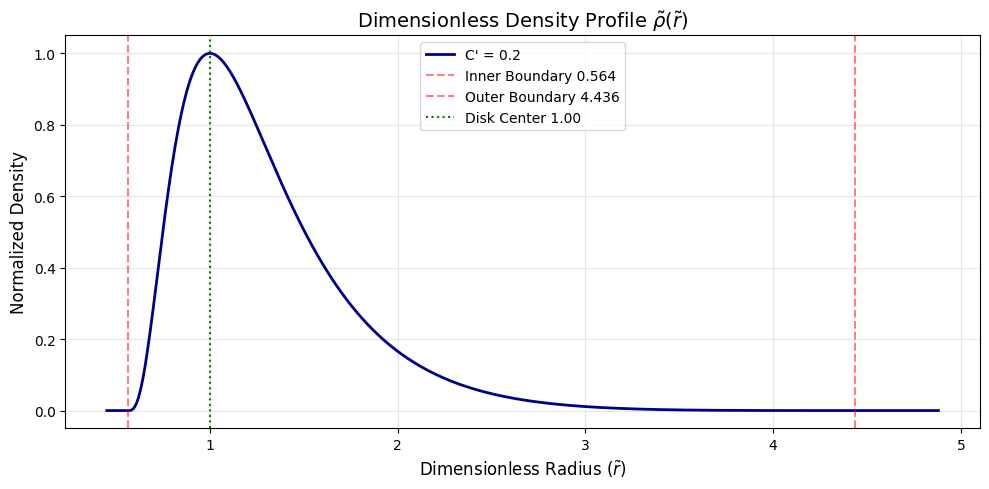

In [11]:
# ==============================================================================
# 5. INITIAL DENSITY PROFILE VISUALIZATION
# ==============================================================================

# Create a dimensionless radial grid covering the disk
r_grid = np.linspace(r_in * 0.8, r_out * 1.1, 500)

# Calculate dimensionless density
rho_tilde = np.zeros_like(r_grid)
for i, r in enumerate(r_grid):
    x = GRID['r_center'] / r
    f_r = x - 0.5 * x**2 - GRID['C_prime']
    if f_r > 0:
        rho_tilde[i] = (f_r / (0.5 - GRID['C_prime']))**n_poly

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(r_grid, rho_tilde, lw=2, color='darkblue', label=f"C' = {GRID['C_prime']}")
plt.axvline(r_in, color='red', linestyle='--', alpha=0.5, label=f'Inner Boundary {r_in:.3f}')
plt.axvline(r_out, color='red', linestyle='--', alpha=0.5, label=f'Outer Boundary {r_out:.3f}')
plt.axvline(GRID['r_center'], color='green', linestyle=':', label=f'Disk Center {GRID["r_center"]:.2f}')

plt.title('Dimensionless Density Profile $\\tilde{\\rho}(\\tilde{r})$', fontsize=14)
plt.xlabel('Dimensionless Radius ($\\tilde{r}$)', fontsize=12)
plt.ylabel('Normalized Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# ==============================================================================
# 6. COMPLETE ATHINPUT FILE GENERATOR
# ==============================================================================

viscosity_method = "Alpha Prescription" if USE_ALPHA_VISCOSITY else "Evolution Time Control"

athinput_content = f"""<comment>
problem   = Thermally-Scaled Papaloizou-Pringle Accretion Disk
configure = --prob=acc_disk --coord=cylindrical

<job>
problem_id = acc_disk

<output1>
file_type  = tab        # Table output format for 1D/2D diagnostics
variable   = prim       # Output primitive variables (rho, v, p)
dt         = {dt_out:.5e}      # Output timestep (every {1/SIM['frames_per_orbit']:.1f} frames per orbit)
dcycle     = -1         # Disable cycle-based output

<time>
cfl_number = 0.4        # Strict CFL for stability during viscous shearing
nlim       = -1         # No cycle limit
tlim       = {tlim:.5e}     # Total simulation duration ({SIM['N_orbits']:.0f} orbits)
integrator = vl2        # Van Leer predictor-corrector (2nd order)
xorder     = 2          # Piecewise linear reconstruction
ncycle_out = 50         # Console output frequency

<mesh>
# Radial direction (x1 = r)
nx1    = 64            # Increased radial resolution for better shock capturing
x1min  = {r_in * 0.5:.3f}            # Inner boundary (50% of r_in)
x1max  = {r_out * 1.5:.3f}            # Outer boundary (150% of r_out)
x1rat  = 1.0            # Uniform spacing
ix1_bc = outflow        # Accretion sink at the inner boundary
ox1_bc = outflow        # Free outflow at the outer boundary

# Azimuthal direction (x2 = phi)
nx2    = 64            # Azimuthal resolution for 2D mode growth
x2min  = 0.0            
x2max  = 6.28318530718  # 2*pi
ix2_bc = periodic       
ox2_bc = periodic

# Vertical direction (x3 = z)
nx3    = 1              # 2D Simulation (equatorial plane)
x3min  = -0.5
x3max  = 0.5
ix3_bc = periodic
ox3_bc = periodic

<meshblock>
nx1 = 16                # MeshBlock size (for MPI parallelization)
nx2 = 16                # Recommended: 32-64 cells per dimension
nx3 = 1

<hydro>
gamma  = {TARGET['gamma']:.11f}  # Adiabatic index
dfloor = 1.0e-8         # Density vacuum floor
pfloor = 1.0e-10        # Pressure vacuum floor

<problem>
# Geometric configuration
r_center = {GRID['r_center']}         # Dimensionless location of the disk center (R_0/r_0)
C_prime  = {GRID['C_prime']}          # Geometric thickness parameter (< 0.5)
nu_iso   = {nu_0:.5e}                 # Kinematic viscosity (Method: {viscosity_method})

# Physical properties for thermal scaling (CGS)
T_0      = {TARGET['T_0']:.2e}        # Reference temperature [K]
mu       = {TARGET['mu']}             # Mean molecular weight
chi      = {TARGET['chi']:.2e}        # Spatial scaling parameter (r_0 / r_g)

# ==============================================================================
# PRE-PROCESSING PARAMETERS (Dimensionless Quantities)
# ==============================================================================
# Sound speed (cs0)         : {cs0:.6e} cm/s ({cs0/1e5:.3f} km/s)
# Polytropic index (n_poly) : {n_poly:.6f}
# Beta parameter            : {beta:.6e}
# Disk inner radius (r_in)  : {r_in:.6f} (dimensionless)
# Disk outer radius (r_out) : {r_out:.6f} (dimensionless)
# Orbital period (P_tilde)  : {P_tilde:.6e} (dimensionless)
# Output timestep (dt_out)  : {dt_out:.6e} (dimensionless)
# Total runtime (tlim)      : {tlim:.6e} (dimensionless)
#
# ==============================================================================
# VISCOSITY CONTROL (Two Methods Available)
# ==============================================================================
# ACTIVE METHOD: {viscosity_method}
# Selected nu_iso           : {nu_0:.6e} (dimensionless)
# Selected tau_visc         : {tau_visc_tilde:.6e} (dimensionless)
# Selected N_orbits         : ~{tau_visc_tilde / P_tilde:.0f} orbits
#
# --- Method 1: Shakura-Sunyaev Alpha Prescription ---
# This method derives viscosity from turbulent disk physics:
#   nu_iso = alpha * gamma * sqrt(beta) * [(0.5 - C') / (n+1)] * sqrt(R_0)
#
# Input:  alpha             : {GRID['alpha']}
# Output: nu_iso (alpha)    : {nu_alpha:.6e}
#         tau_visc          : {tau_visc_alpha:.6e}
#         N_orbits needed   : ~{N_orbits_alpha:.0f} orbits
#
# --- Method 2: Direct Evolution Time Control ---
# This method sets viscosity to achieve a target accretion timescale:
#   nu_iso = (1/N) * sqrt(beta * R_0) / (2*pi)
# where N is the desired number of orbits for significant accretion.
#
# Input:  N_desired         : {N_desired:.0f} orbits
# Output: nu_iso (N-control): {nu_evolution:.6e}
#         tau_visc          : {tau_visc_evolution:.6e}
#
# ==============================================================================
# POST-PROCESSING PARAMETERS (Physical Units)
# ==============================================================================
# Black hole mass           : {TARGET['M_BH_sun']:.2e} M_sun
# Schwarzschild radius (r_g): {r_g:.6e} cm
# Length scale (r_0)        : {r_0:.6e} cm ({r_0/CONST['PC']:.4f} pc)
# Velocity scale (v_0=cs0)  : {v_0/1e5:.3f} km/s
# Time scale (t_0)          : {t_0:.6e} s ({t_0/CONST['YR']:.2e} yr)
#
# DISK GEOMETRY:
# Inner radius (R_in)       : {R_in_pc:.4f} pc
# Outer radius (R_out)      : {R_out_pc:.4f} pc
#
# TIMESCALES:
# One orbital period        : {P_phys_yr:.2f} yr
# Viscous timescale         : {tau_visc_yr:.2e} yr
# Orbits for accretion      : ~{tau_visc_tilde / P_tilde:.0f} orbits
#
# ==============================================================================
"""

print(athinput_content)

<comment>
problem   = Thermally-Scaled Papaloizou-Pringle Accretion Disk
configure = --prob=acc_disk --coord=cylindrical

<job>
problem_id = acc_disk

<output1>
file_type  = tab        # Table output format for 1D/2D diagnostics
variable   = prim       # Output primitive variables (rho, v, p)
dt         = 1.01227e-03      # Output timestep (every 0.1 frames per orbit)
dcycle     = -1         # Disable cycle-based output

<time>
cfl_number = 0.4        # Strict CFL for stability during viscous shearing
nlim       = -1         # No cycle limit
tlim       = 5.06133e-01     # Total simulation duration (50 orbits)
integrator = vl2        # Van Leer predictor-corrector (2nd order)
xorder     = 2          # Piecewise linear reconstruction
ncycle_out = 50         # Console output frequency

<mesh>
# Radial direction (x1 = r)
nx1    = 64            # Increased radial resolution for better shock capturing
x1min  = 0.282            # Inner boundary (50% of r_in)
x1max  = 6.655            # Outer 